# Feature Masking Experiment

This notebook implements the Feature Masking experiment described in Section 4.2 of the Report.
We evaluate the relative importance of text and audio features (Pitch, Energy) by masking them and measuring model performance.
We also analyze Cross-Attention patterns.

In [1]:
# Install dependencies if missing
!pip install praat-parselmouth

zsh:1: command not found: pip


In [2]:
import sys
import os
sys.path.append(os.path.abspath('src'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import parselmouth
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from dataset import IEMOCAPDataset
from model import MultimodalEmotionModel
from config import BATCH_SIZE, EMOTIONS, ID2EMOTION, SAMPLE_RATE
from torch.utils.data import DataLoader
from xai.attention_viz import AttentionVisualizer

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

In [3]:
# Device configuration
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

# Load Model
MODEL_PATH = '../models/best_model.pt'
if not os.path.exists(MODEL_PATH):
    MODEL_PATH = 'models/best_model.pt'

print(f"Loading model from {MODEL_PATH}...")
model = MultimodalEmotionModel().to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded successfully.")

Using device: mps
Loading model from ../models/best_model.pt...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully.


## Masking Functions

We define functions to mask Pitch and Energy.

In [4]:
def mask_pitch(audio_np, sr=16000):
    """
    Flatten pitch using Praat (Parselmouth).
    """
    try:
        snd = parselmouth.Sound(audio_np, sampling_frequency=sr)
        manipulation = parselmouth.praat.call(snd, "To Manipulation", 0.01, 75, 600)
        pitch_tier = parselmouth.praat.call(manipulation, "Extract pitch tier")
        
        # Flatten pitch: set all points to mean pitch
        mean_pitch = parselmouth.praat.call(pitch_tier, "Get mean (curve)...", 0, 0)
        if np.isnan(mean_pitch):
             mean_pitch = 150 # Default fallback
             
        # Remove all points and add constant points
        parselmouth.praat.call(pitch_tier, "Remove points between", 0, snd.duration)
        parselmouth.praat.call(pitch_tier, "Add point", 0.0, mean_pitch)
        parselmouth.praat.call(pitch_tier, "Add point", snd.duration, mean_pitch)
        
        parselmouth.praat.call([pitch_tier, manipulation], "Replace pitch tier")
        snd_resynth = parselmouth.praat.call(manipulation, "Get resynthesis (overlap-add)")
        return snd_resynth.values[0]
    except Exception as e:
        # print(f"Pitch masking failed: {e}")
        return audio_np # Fallback

def mask_energy(audio_np):
    """
    Normalize energy to be constant (remove amplitude dynamics).
    Uses Hilbert envelope normalization.
    """
    epsilon = 1e-6
    from scipy.signal import hilbert
    analytic_signal = hilbert(audio_np)
    amplitude_envelope = np.abs(analytic_signal)
    
    # Avoid division by zero
    amplitude_envelope = np.maximum(amplitude_envelope, epsilon)
    
    # Flattened
    audio_flat = audio_np / amplitude_envelope
    # Scale back to average amplitude
    avg_amp = np.mean(amplitude_envelope)
    audio_flat = audio_flat * avg_amp
    
    return audio_flat

## Experiment Loop

We iterate through the test set and apply different masking conditions.
**Note:** For demonstration, we limit to 50 samples. Remove `break` to run on full dataset.

In [5]:
# Conditions
CONDITIONS = [
    'Baseline',
    'Pitch Masking',
    'Energy Masking',
    'Pitch+Energy Masking',
    'Text Only',
    'Audio Only'
]

results = {c: {'preds': [], 'labels': []} for c in CONDITIONS}

# Load Test Data
print("Loading test data...")
test_ds = IEMOCAPDataset(split='test')
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False) # Batch size 1 for easier masking

N_SAMPLES = 50 # Limit for demo
print(f"Starting experiments on {N_SAMPLES} samples (Total: {len(test_ds)})...")

for idx, batch in enumerate(tqdm(test_loader)):
    if idx >= N_SAMPLES:
        break
        
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    audio = batch['audio'].to(device)
    audio_mask = batch['audio_mask'].to(device)
    labels = batch['label'].to(device)
    
    # Original Audio (numpy)
    audio_np = audio.cpu().numpy()[0]
    
    for condition in CONDITIONS:
        # Prepare inputs based on condition
        curr_input_ids = input_ids
        curr_attn_mask = attention_mask
        curr_audio = audio
        curr_audio_mask = audio_mask
        
        # 1. Text Only (Mask Audio)
        if condition == 'Text Only':
            curr_audio = torch.zeros_like(audio)
            
        # 2. Audio Only (Mask Text)
        elif condition == 'Audio Only':
            curr_attn_mask = torch.zeros_like(attention_mask)
            
        # 3. Pitch Masking
        elif condition == 'Pitch Masking':
            masked_audio_np = mask_pitch(audio_np)
            if len(masked_audio_np) != len(audio_np):
                if len(masked_audio_np) > len(audio_np):
                    masked_audio_np = masked_audio_np[:len(audio_np)]
                else:
                    masked_audio_np = np.pad(masked_audio_np, (0, len(audio_np)-len(masked_audio_np)))
            curr_audio = torch.tensor(masked_audio_np, dtype=torch.float32).unsqueeze(0).to(device)

        # 4. Energy Masking
        elif condition == 'Energy Masking':
            masked_audio_np = mask_energy(audio_np)
            curr_audio = torch.tensor(masked_audio_np, dtype=torch.float32).unsqueeze(0).to(device)
            
        # 5. Pitch+Energy Masking
        elif condition == 'Pitch+Energy Masking':
            masked_audio_np = mask_pitch(audio_np)
            masked_audio_np = mask_energy(masked_audio_np)
            if len(masked_audio_np) > len(audio_np):
                 masked_audio_np = masked_audio_np[:len(audio_np)]
            elif len(masked_audio_np) < len(audio_np):
                 masked_audio_np = np.pad(masked_audio_np, (0, len(audio_np)-len(masked_audio_np)))
            curr_audio = torch.tensor(masked_audio_np, dtype=torch.float32).unsqueeze(0).to(device)
            
        # Inference
        with torch.no_grad():
            outputs = model(curr_input_ids, curr_attn_mask, curr_audio, curr_audio_mask)
            logits = outputs['logits']
            pred = torch.argmax(logits, dim=1).item()
            
        results[condition]['preds'].append(pred)
        results[condition]['labels'].append(labels.item())

Loading test data...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AbstractTTS/IEMOCAP' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading AbstractTTS/IEMOCAP...


Loaded 1376 samples for split 'test'
Starting experiments on 50 samples (Total: 1376)...


  0%| | 0/1376 [00:00<?, ?i

...

  3%| | 47/1376 [00:11<05:1

  3%| | 48/1376 [00:12<05:2

  4%| | 49/1376 [00:12<05:2

  4%| | 50/1376 [00:12<05:2

  4%| | 50/1376 [00:12<05:3

## Results Analysis

We calculate Accuracy and F1-Score for each condition.

In [6]:
# Compute Metrics
metrics_data = []

for cond in CONDITIONS:
    preds = results[cond]['preds']
    labels = results[cond]['labels']
    
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    
    metrics_data.append({
        'Condition': cond,
        'Accuracy': acc,
        'Weighted F1': f1
    })

metrics_df = pd.DataFrame(metrics_data)
print("Table 4.1: Feature Masking Results")
print(metrics_df)

Table 4.1: Feature Masking Results
              Condition  Accuracy  Weighted F1
0              Baseline      0.68     0.654865
1         Pitch Masking      0.60     0.566391
2        Energy Masking      0.44     0.377780
3  Pitch+Energy Masking      0.42     0.342747
4             Text Only      0.36     0.228421
5            Audio Only      0.40     0.262348


/var/folders/3w/rndb5hj13j58ts_3ckjychc40000gn/T/ipykernel_5214/549053235.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Condition', y='Accuracy', palette='viridis')


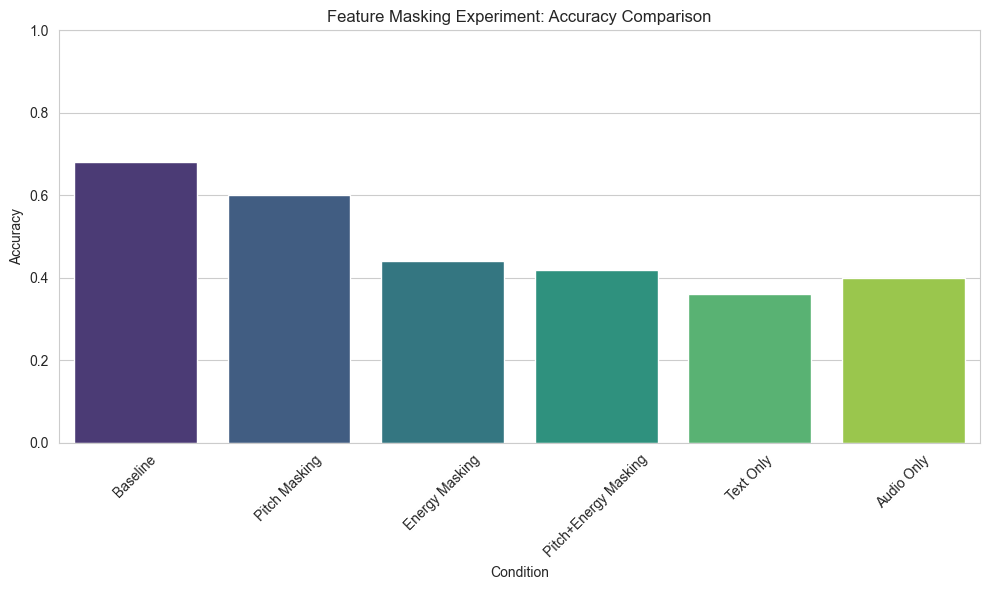

In [7]:
# Figure 4.5: Accuracy Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_df, x='Condition', y='Accuracy', palette='viridis')
plt.title('Feature Masking Experiment: Accuracy Comparison')
plt.xticks(rotation=45)
plt.ylim(0, 1.0)
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/feature_masking_accuracy.png')
plt.show()

/Users/sangyub/Desktop/xai_2/multimodal_xai/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sangyub/Desktop/xai_2/multimodal_xai/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sangyub/Desktop/xai_2/multimodal_xai/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


Table 4.2: Emotion-wise F1 Scores
Condition  Audio Only  Baseline  Energy Masking  Pitch Masking  \
Emotion                                                          
ang          0.842105  0.500000        0.200000       0.500000   
hap          0.000000  0.702703        0.538462       0.631579   
neu          0.461538  0.588235        0.153846       0.400000   
sad          0.000000  0.764706        0.509804       0.685714   

Condition  Pitch+Energy Masking  Text Only  
Emotion                                     
ang                    0.200000   0.333333  
hap                    0.560000   0.526316  
neu                    0.000000   0.000000  
sad                    0.490566   0.000000  


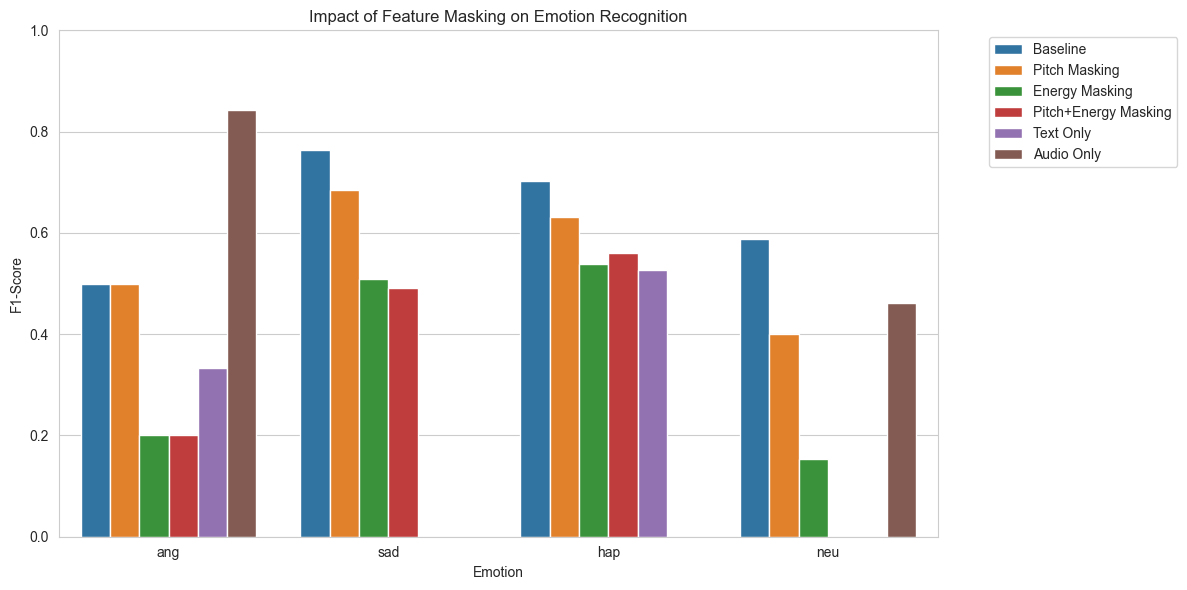

In [8]:
# Figure 4.6: Emotion-wise F1 Comparison
emotion_f1_data = []

for cond in CONDITIONS:
    preds = results[cond]['preds']
    labels = results[cond]['labels']
    
    report = classification_report(labels, preds, target_names=list(ID2EMOTION.values()), output_dict=True)
    
    for emo in ID2EMOTION.values():
        emotion_f1_data.append({
            'Condition': cond,
            'Emotion': emo,
            'F1-Score': report[emo]['f1-score']
        })

emo_f1_df = pd.DataFrame(emotion_f1_data)
print("Table 4.2: Emotion-wise F1 Scores")
print(emo_f1_df.pivot(index='Emotion', columns='Condition', values='F1-Score'))

plt.figure(figsize=(12, 6))
sns.barplot(data=emo_f1_df, x='Emotion', y='F1-Score', hue='Condition')
plt.title('Impact of Feature Masking on Emotion Recognition')
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('results/feature_masking_emotion_f1.png')
plt.show()

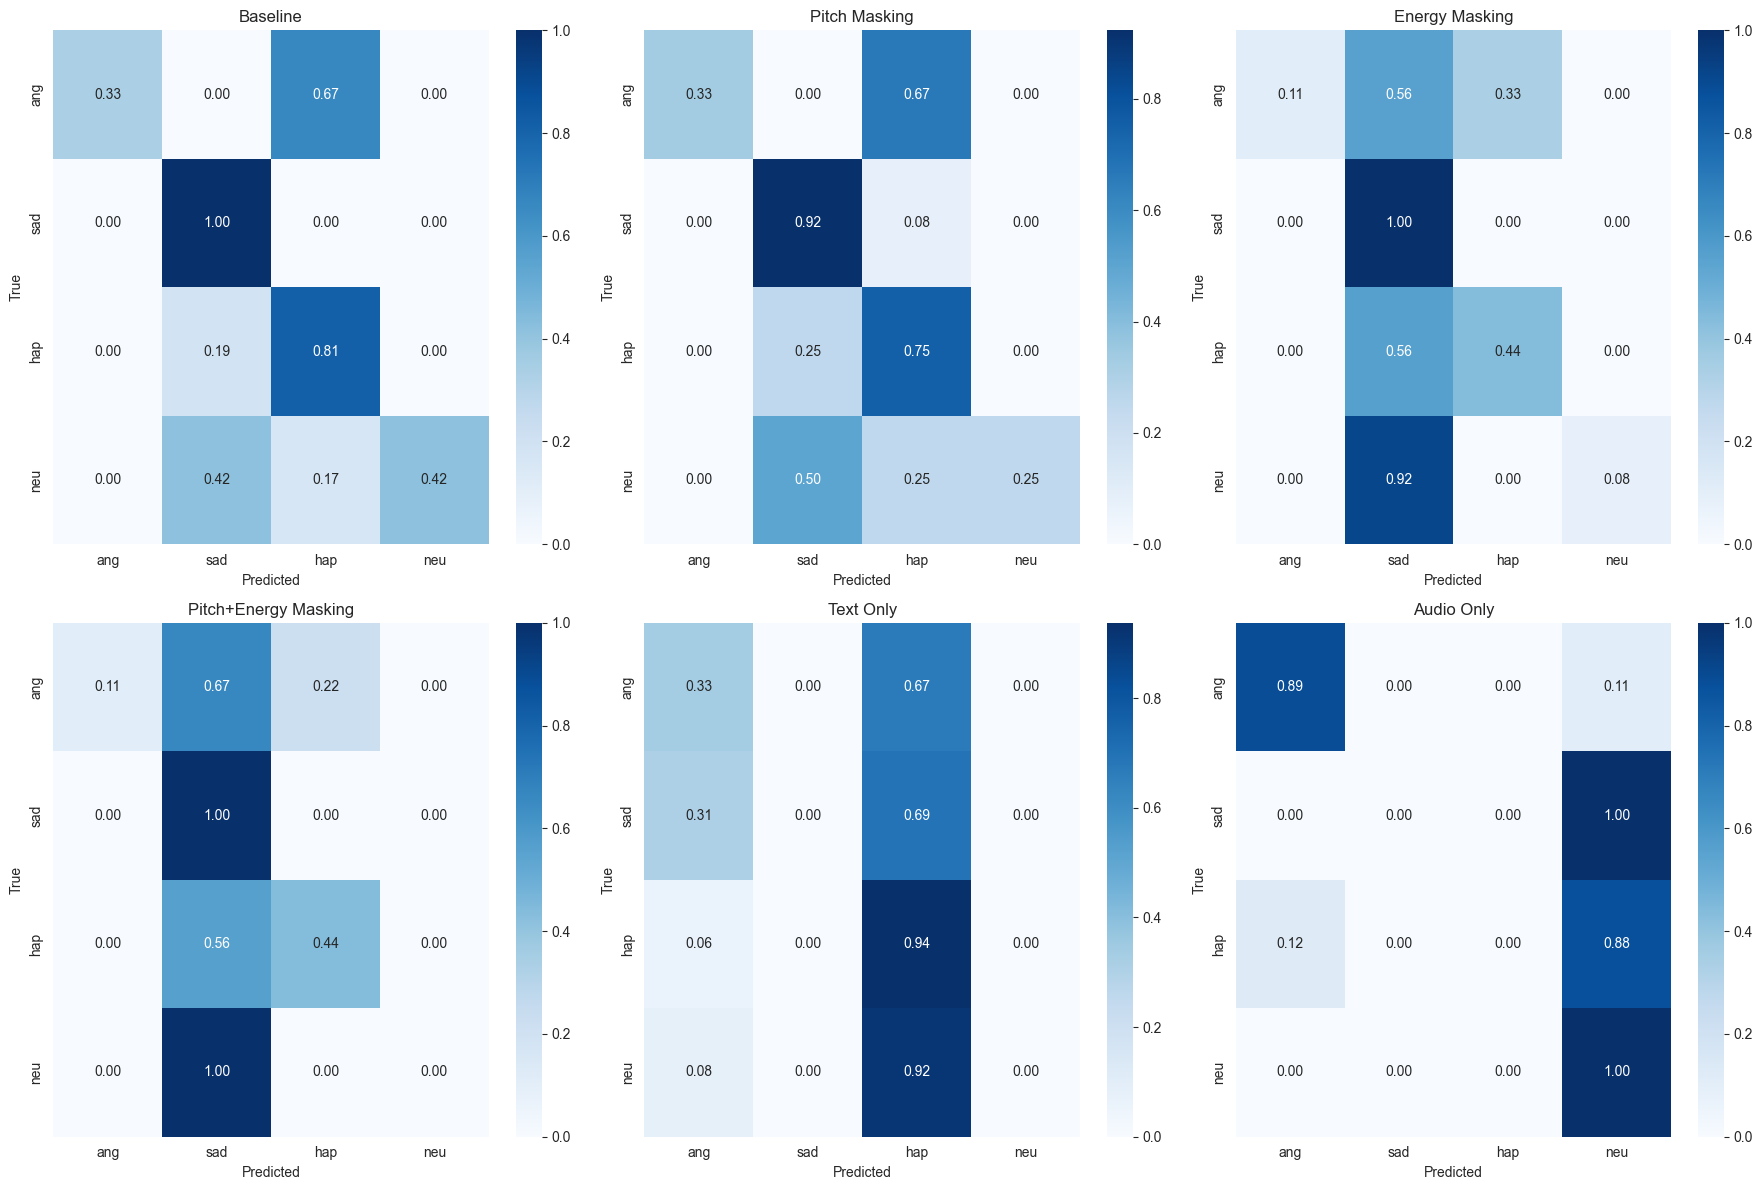

In [9]:
# Figure 4.7: Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, cond in enumerate(CONDITIONS):
    preds = results[cond]['preds']
    labels = results[cond]['labels']
    cm = confusion_matrix(labels, preds)
    
    # Normalize
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[idx], 
                xticklabels=list(ID2EMOTION.values()), yticklabels=list(ID2EMOTION.values()))
    axes[idx].set_title(f'{cond}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.savefig('results/feature_masking_confusion_matrices.png')
plt.show()

## Cross-Attention Analysis (Figure 4.8)

We visualize the Cross-Attention weights to see how text and audio align.

In [10]:
viz = AttentionVisualizer()
output_dir = 'results/attention_maps'
os.makedirs(output_dir, exist_ok=True)

# Collect one sample per emotion
samples_to_viz = {}
emotions_needed = set(ID2EMOTION.values())

print("Collecting samples for Attention Visualization...")
for idx, batch in enumerate(test_loader):
    if len(samples_to_viz) >= 4:
        break
        
    label_idx = batch['label'].item()
    emotion = ID2EMOTION[label_idx]
    
    if emotion in emotions_needed and emotion not in samples_to_viz:
        # Run inference to get attention weights
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        audio = batch['audio'].to(device)
        audio_mask = batch['audio_mask'].to(device)
        
        with torch.no_grad():
            outputs = model(input_ids, attention_mask, audio, audio_mask)
            attn_weights = outputs.get('attention_weights', None)
            
        if attn_weights is not None:
            samples_to_viz[emotion] = {
                'id': idx,
                'input_ids': input_ids[0].cpu(),
                'attention_weights': attn_weights,
                'label': emotion
            }

# Plot
for emotion, sample in samples_to_viz.items():
    viz.plot_attention_heatmap(
        attention_weights=sample['attention_weights'],
        text_tokens=sample['input_ids'],
        audio_duration=6.0,
        sample_id=sample['id'],
        true_label=sample['label'],
        pred_label="N/A",
        save_path=f"{output_dir}/attention_{emotion}.png",
        title=f"Cross-Attention: {emotion.upper()}"
    )
    print(f"Saved attention map for {emotion}")

✅ Saved: results/attention_maps/attention_ang.png
Saved attention map for ang
✅ Saved: results/attention_maps/attention_hap.png
Saved attention map for hap


✅ Saved: results/attention_maps/attention_sad.png
Saved attention map for sad
✅ Saved: results/attention_maps/attention_neu.png
Saved attention map for neu
